# Final Project

## Part 0 Project Proposal
Before we do the project, you will need to create a repository
1. Create the project remotely on GitHub.  You will want to include a README
2. Install GitHub Desktop.
3. From the remote repo, clone down to your local and use github desktop to create it.
4. Copy the notebook into your local repo
5. Commit and push

***Invite me and the GA to your repo***

As you make changes locally, commit and push them. 

To complete the proposal. You will record the following in your README

1. The kind of data you want to find
2. The question/s you want to answer with the data.
3. URLs for the site/s that have the data you want.

***Note: You must aquire the data via an API or Web scraping.  Downloading a file will not get points.***

All code for your project will be recorded in this note book. Create extra code cells as needed.


# Part 1: Data aquisition
    1. Get raw data and put it into files. If needed, gather a representative amount of data.  Then append additional data as available.
    


In [ ]:
import pandas as pd
import io
import json
import time
from datetime import datetime
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

def scrape_nba_total_efficiency():
    chrome_options = Options()
    chrome_options.add_argument("--disable-blink-features=AutomationControlled")
    driver = webdriver.Chrome(options=chrome_options)
    
    master_data = {}
    current_year = 2026 # Updated for the 2025-26 season
    years = list(range(1980, current_year + 1)) 

    try:
        for year in years:
            url = f"https://www.basketball-reference.com/leagues/NBA_{year}.html"
            print(f"📊 Extraction: {year} Season...")
            driver.get(url)

            # --- Dismiss Privacy Banner ---
            try:
                wait = WebDriverWait(driver, 3)
                btn = wait.until(EC.element_to_be_clickable((By.CLASS_NAME, "osano-cm-accept-all")))
                btn.click()
            except:
                pass 

            # --- Advanced Table Extraction ---
            try:
                table_element = WebDriverWait(driver, 10).until(
                    EC.presence_of_element_located((By.ID, "advanced-team"))
                )
                
                table_html = table_element.get_attribute('outerHTML')
                df = pd.read_html(io.StringIO(table_html))[0]
                
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(-1)
                
                # THE ULTIMATE STAT LIST
                # eFG%, TOV%, ORB%, FT/FGA are the 'Four Factors'
                target_cols = ['Team', 'Pace', 'ORtg', 'DRtg', 'NRtg', 'TS%', 'eFG%', 'TOV%', 'ORB%', 'FT/FGA']
                
                available_cols = [c for c in target_cols if c in df.columns]
                clean_df = df[available_cols].dropna()
                clean_df = clean_df[~clean_df['Team'].str.contains("League Average", na=False)]
                
                master_data[year] = clean_df.set_index('Team').to_dict(orient='index')
                print(f"   ✅ Data saved for {year}")
                
            except Exception as e:
                print(f"   ⚠️ Skipping {year} (Data likely unavailable yet)")

            # Respect the site's rate limits
            time.sleep(4) 

    finally:
        driver.quit()
        with open("data/raw/nba_history_efficiency.json", "w") as f:
            json.dump(master_data, f, indent=4)
        print(f"\n🚀 Total History Exported! File: nba_total_efficiency_1980_2026.json")

scrape_nba_total_efficiency()

📊 Extraction: 1980 Season...


C:\Users\s548941\AppData\Local\Temp\ipykernel_16496\3055026742.py:55: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  master_data[year] = clean_df.set_index('Team').to_dict(orient='index')


   ✅ Data saved for 1980
📊 Extraction: 1981 Season...


C:\Users\s548941\AppData\Local\Temp\ipykernel_16496\3055026742.py:55: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  master_data[year] = clean_df.set_index('Team').to_dict(orient='index')


   ✅ Data saved for 1981
📊 Extraction: 1982 Season...


...

   ✅ Data saved for 2024
📊 Extraction: 2025 Season...


C:\Users\s548941\AppData\Local\Temp\ipykernel_16496\3055026742.py:55: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  master_data[year] = clean_df.set_index('Team').to_dict(orient='index')


   ✅ Data saved for 2025
📊 Extraction: 2026 Season...


C:\Users\s548941\AppData\Local\Temp\ipykernel_16496\3055026742.py:55: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  master_data[year] = clean_df.set_index('Team').to_dict(orient='index')


   ✅ Data saved for 2026

🚀 Total History Exported! File: nba_total_efficiency_1980_2026.json


## Part 2 Data processing

1. Process the raw data and store results in a file as needed.
2. Do analysis of the data
   

In [ ]:
import pandas as pd
import json
import os

def process_nba_json():
    # 1. Load the raw data
    input_file = "data/raw/nba_history_efficiency.json"
    if not os.path.exists(input_file):
        print(f"❌ Error: {input_file} not found!")
        return

    with open(input_file, 'r') as f:
        raw_data = json.load(f)

    # Create the folder structure
    os.makedirs('data/processed', exist_ok=True)

    # 2. Flatten the JSON into a single DataFrame with Filtering
    all_rows = []
    for year, teams in raw_data.items():
        for team_name, stats in teams.items():
            
            # --- THE GHOST ROW FILTER ---
            # Skip if the name is 'Team' (header repeat), empty, or None
            if not team_name or str(team_name).strip() in ["", "Team", "None"]:
                continue
            
            # Skip rows that are clearly just league averages if they snuck in
            if "League Average" in str(team_name):
                continue

            row = {'Year': int(year), 'Team': team_name}
            row.update(stats)
            all_rows.append(row)

    master_df = pd.DataFrame(all_rows)

    # --- NUMERIC CONVERSION & SECONDARY CLEANUP ---
    cols_to_fix = ['Pace', 'ORtg', 'DRtg', 'NRtg', 'TS%', 'eFG%', 'TOV%', 'ORB%', 'FT/FGA']
    for col in cols_to_fix:
        if col in master_df.columns:
            master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

    # Drop any rows where EVERY stat is NaN (safety net for empty rows)
    master_df = master_df.dropna(subset=[c for c in cols_to_fix if c in master_df.columns], how='all')

    # --- FILE 1: Team Efficiency Trends ---
    master_df = master_df.round(3)
    master_df.to_csv('data/processed/team_efficiency_trends.csv', index=False)
    print("✅ Created: team_efficiency_trends.csv")

    # --- FILE 2: League Yearly Averages ---
    league_avg = master_df.groupby('Year').mean(numeric_only=True).reset_index()
    league_avg = league_avg.round(3)
    league_avg.to_csv('data/processed/league_yearly_averages.csv', index=False)
    print("✅ Created: league_yearly_averages.csv")

    print("\n🚀 All files processed and cleaned! Check data/processed/")

process_nba_json()

✅ Created: team_efficiency_trends.csv
✅ Created: league_yearly_averages.csv
✅ Created: shooting_evolution.csv

🚀 All files processed and cleaned! Check data/processed/


In [ ]:
import pandas as pd
import json
import os

def process_nba_json_cleaned():
    input_file = "data/raw/nba_history_efficiency.json"
    if not os.path.exists(input_file):
        print("❌ Error: Raw JSON not found!")
        return

    with open(input_file, 'r') as f:
        raw_data = json.load(f)

    all_rows = []
    for year, teams in raw_data.items():
        for team_name, stats in teams.items():
            # Filter out the 'Team' headers and 'League Average'
            if not team_name or str(team_name).strip() in ["", "Team", "None", "League Average"]:
                continue

            row = {'Year': int(year), 'Team': team_name}
            row.update(stats)
            all_rows.append(row)

    master_df = pd.DataFrame(all_rows)

    # --- THE MAGIC FIX: UNIFY TEAM NAMES ---
    # This removes the '*' from 'Boston Celtics*' so it matches 'Boston Celtics'
    master_df['Team'] = master_df['Team'].str.replace('*', '', regex=False).str.strip()

    # Convert stats to numbers
    cols_to_fix = ['Pace', 'ORtg', 'DRtg', 'NRtg', 'TS%', 'eFG%', 'TOV%', 'ORB%', 'FT/FGA']
    for col in cols_to_fix:
        if col in master_df.columns:
            master_df[col] = pd.to_numeric(master_df[col], errors='coerce')

    # Round everything to 3 decimals
    master_df = master_df.round(3)

    # Save the cleaned files
    os.makedirs('data/processed', exist_ok=True)
    master_df.to_csv('data/processed/team_efficiency_trends.csv', index=False)
    
    # Update the averages too
    league_avg = master_df.groupby('Year').mean(numeric_only=True).reset_index().round(3)
    league_avg.to_csv('data/processed/league_yearly_averages.csv', index=False)

    print("✅ Success! Asterisks removed and teams unified in all CSVs.")


process_nba_json_cleaned()

✅ Success! Asterisks removed and teams unified in all CSVs.


# NBA Historical Efficiency Scraping: Strategy & Documentation

## Overview
This document outlines the rationale behind the specific data points collected during the 1980–2026 NBA efficiency scraping project. These metrics were selected to provide a multi-dimensional view of how basketball has evolved from the introduction of the three-point line to the modern "pace and space" era.

## 1. Core Efficiency Metrics
These are the primary indicators of a team's performance relative to the number of possessions played, rather than just total points.

* **ORtg (Offensive Rating):** Points scored per 100 possessions. This is the gold standard for measuring offensive efficiency because it removes the "noise" of a team's playing speed.
* **DRtg (Defensive Rating):** Points allowed per 100 possessions. This allows us to compare the 1990s "grind-it-out" defenses to modern defenses on an even playing field.
* **NRtg (Net Rating):** The difference between ORtg and DRtg. This is the single best predictor of a team's true quality and championship pedigree.

## 2. Contextual & Style Metrics
These metrics explain *how* a team achieves its efficiency and the environment they played in.

* **Pace:** The estimated number of possessions per 48 minutes. Pace tells the story of the league's speed—from the high-flying 80s to the slow 2000s and the current resurgence in speed.
* **TS% (True Shooting Percentage):** A shooting percentage that accounts for 2-point field goals, 3-point field goals, and free throws. It is the most accurate way to measure a team's scoring efficiency.

## 3. The Four Factors (The "DNA" of Efficiency)
Derived from the work of Dean Oliver, these four stats explain 90% of why a team wins or loses.

* **eFG% (Effective Field Goal Percentage):** Adjusts for the fact that a 3pt shot is worth 50% more than a 2pt shot. This is the primary factor in offensive success.
* **TOV% (Turnover Percentage):** An estimate of turnovers per 100 possessions. This measures a team's ability to protect the ball and maximize every possession.
* **ORB% (Offensive Rebound Percentage):** The percentage of available offensive rebounds a team grabs. This measures "extra chance" generation.
* **FT/FGA (Free Throw Rate):** Measures both a team's ability to get to the line and their aggressiveness. Free throws are the most efficient points in basketball.

## Data Processing Strategy
The raw JSON data is processed into three distinct CSV files to facilitate different types of analysis:

1.  **`team_efficiency_trends.csv`**: Full historical record for every franchise.
2.  **`league_yearly_averages.csv`**: Baseline data to compare individual teams against their specific era.
3.  **`shooting_evolution.csv`**: Dedicated to tracking the "Three-Point Revolution" and shooting efficiency shifts.

---
**Project Goal:** To visualize the "Upward Efficiency Ramp" and identify which teams were the greatest outliers relative to their era's average.

## Part 3 Visualization

1. Create good graphs
2. Give narative conclusions explaining what is being demonstrated in the visualizations.

   

✅ Dashboard successfully saved to: data/graphs/nba_dashboard.png


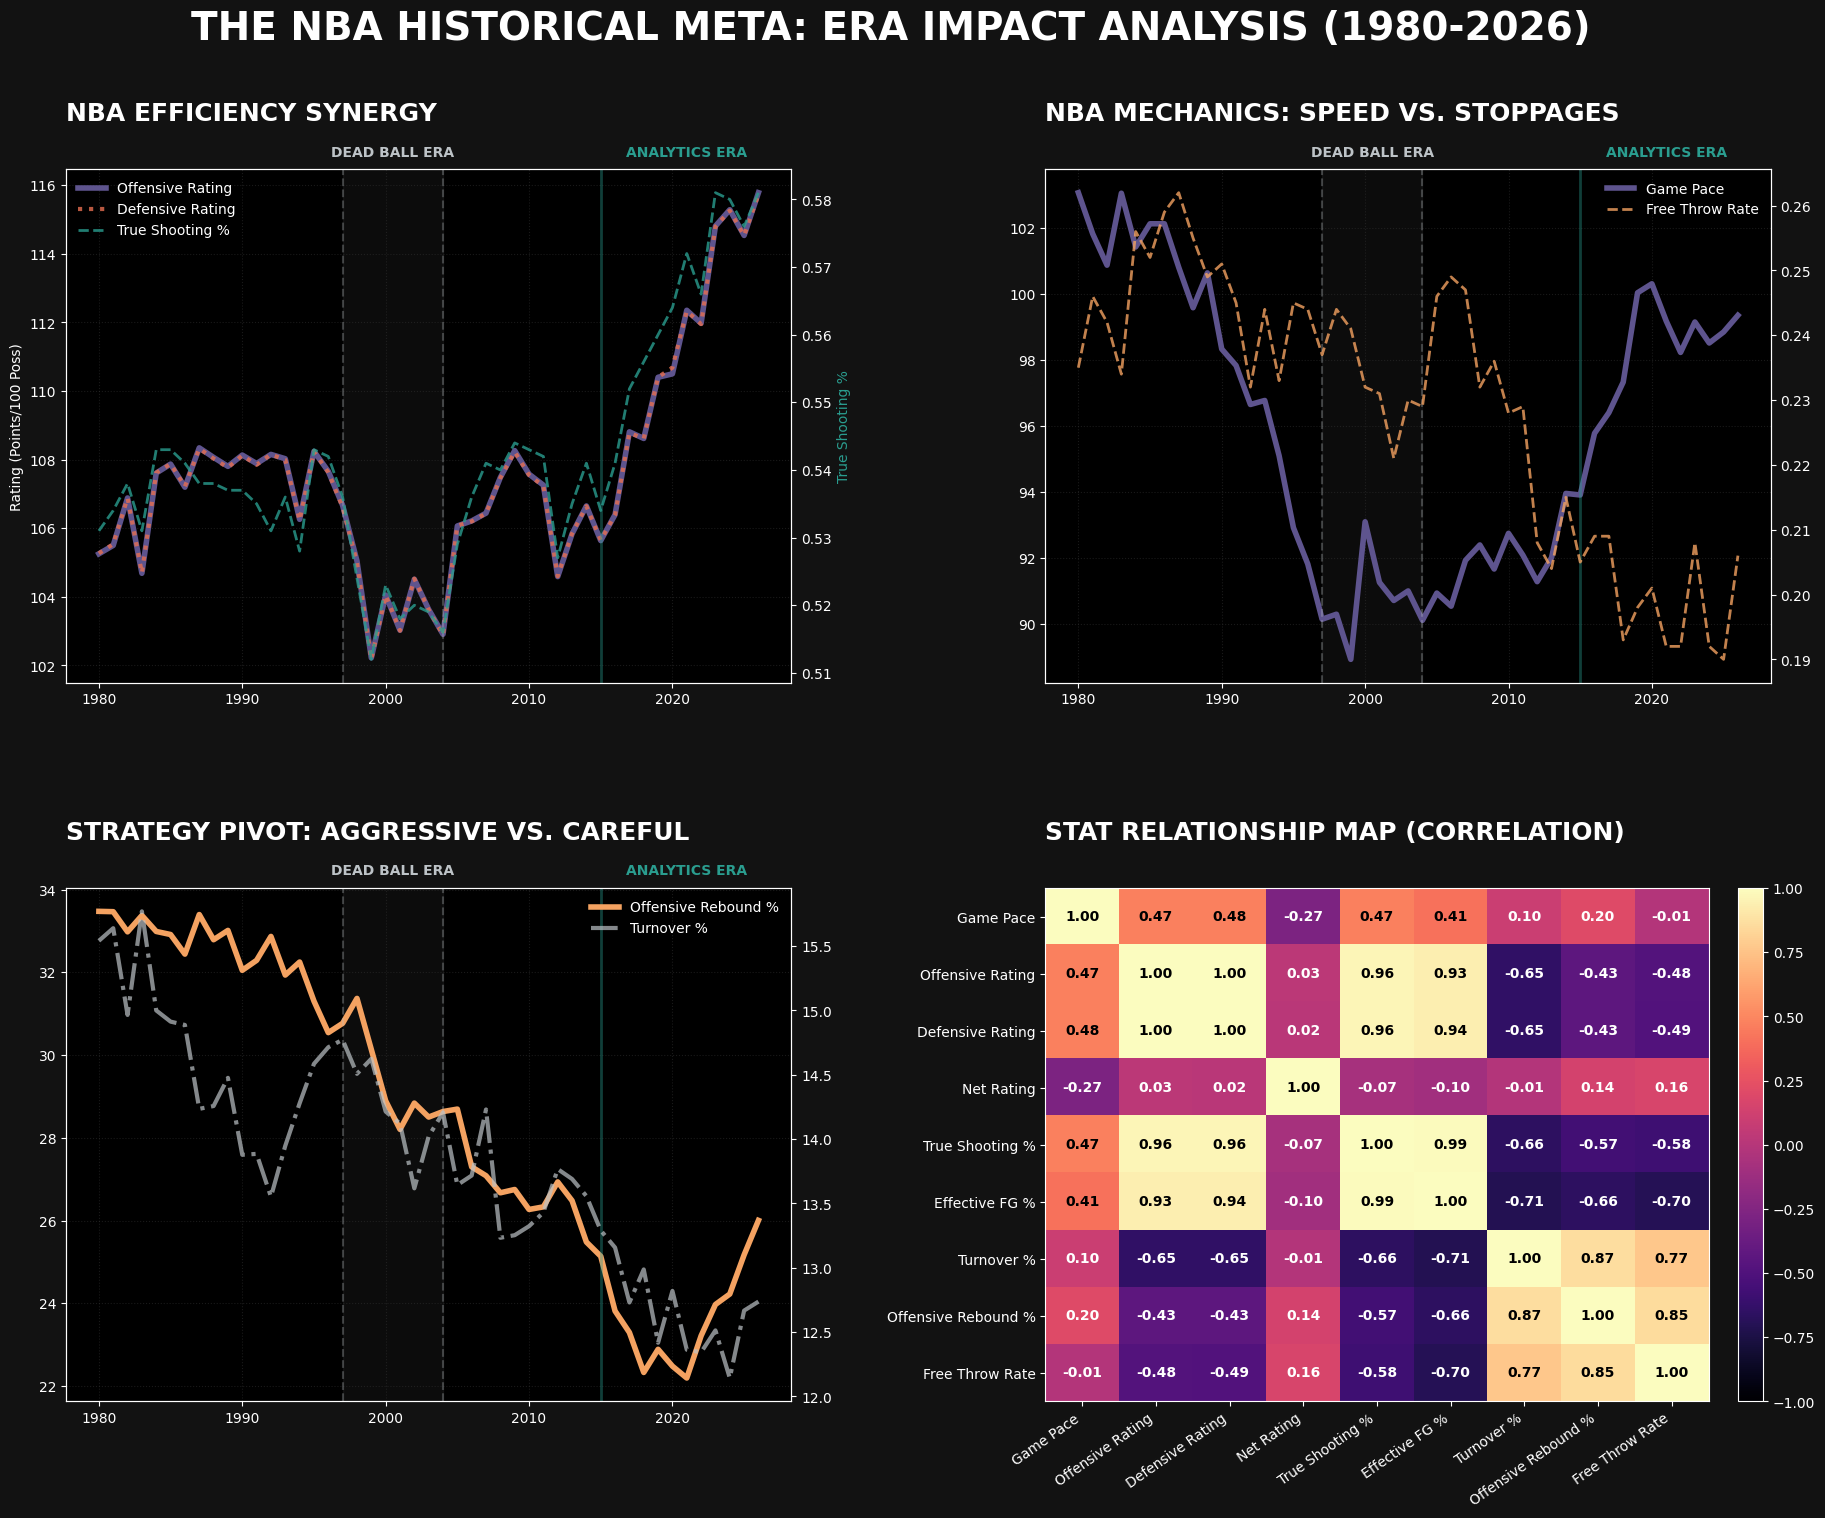

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- STYLE CONFIGURATION ---
PURPLE = '#5e548e'
TEAL = '#2a9d8f'
ORANGE = '#f4a261'
SILVER = '#bdc3c7'
RED = '#e76f51'  # Added for Defensive Rating
DARK_BG = '#121212'
GRID_COLOR = '#333333'
TEXT_COLOR = '#E0E0E0'

def create_complete_nba_dashboard():
    file_path = 'data/processed/league_yearly_averages.csv'
    if not os.path.exists(file_path):
        print(f"❌ Error: {file_path} not found.")
        return

    df = pd.read_csv(file_path).sort_values('Year')
    
    # Mapping for Heatmap Labels
    name_map = {
        'Pace': 'Game Pace', 'ORtg': 'Offensive Rating', 'DRtg': 'Defensive Rating',
        'NRtg': 'Net Rating', 'TS%': 'True Shooting %', 'eFG%': 'Effective FG %',
        'TOV%': 'Turnover %', 'ORB%': 'Offensive Rebound %', 'FT/FGA': 'Free Throw Rate'
    }
    
    # Ensure directory exists
    os.makedirs('data/graphs', exist_ok=True)
    
    corr_df = df.drop(columns=['Year']).rename(columns=name_map)
    corr_matrix = corr_df.corr()

    plt.style.use('dark_background')
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(22, 16), facecolor=DARK_BG)
    plt.subplots_adjust(hspace=0.4, wspace=0.35)

    # --- PANEL 1: EFFICIENCY (ORtg, DRtg, & TS%) ---
    l1, = ax1.plot(df['Year'], df['ORtg'], color=PURPLE, linewidth=4, label='Offensive Rating')
    l2, = ax1.plot(df['Year'], df['DRtg'], color=RED, linewidth=3, linestyle=':', alpha=0.8, label='Defensive Rating')
    
    ax1_t = ax1.twinx()
    l3, = ax1_t.plot(df['Year'], df['TS%'], color=TEAL, linewidth=2, linestyle='--', alpha=0.8, label='True Shooting %')
    
    ax1.set_title('NBA EFFICIENCY SYNERGY', loc='left', fontsize=18, fontweight='black', pad=35)
    ax1.set_ylabel('Rating (Points/100 Poss)')
    ax1_t.set_ylabel('True Shooting %', color=TEAL)
    
    # Combine all three lines into one legend
    lines = [l1, l2, l3]
    ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', frameon=False)

    # --- PANEL 2: MECHANICS ---
    l3_mech, = ax2.plot(df['Year'], df['Pace'], color=PURPLE, linewidth=4, label='Game Pace')
    ax2_t = ax2.twinx()
    l4_mech, = ax2_t.plot(df['Year'], df['FT/FGA'], color=ORANGE, linewidth=2, linestyle='--', alpha=0.8, label='Free Throw Rate')
    ax2.set_title('NBA MECHANICS: SPEED VS. STOPPAGES', loc='left', fontsize=18, fontweight='black', pad=35)
    ax2.legend([l3_mech, l4_mech], [l.get_label() for l in [l3_mech, l4_mech]], loc='upper right', frameon=False)

    # --- PANEL 3: STRATEGY PIVOT ---
    l5, = ax3.plot(df['Year'], df['ORB%'], color=ORANGE, linewidth=4, label='Offensive Rebound %')
    ax3_t = ax3.twinx()
    l6, = ax3_t.plot(df['Year'], df['TOV%'], color=SILVER, linewidth=3, linestyle='-.', alpha=0.7, label='Turnover %')
    ax3.set_title('STRATEGY PIVOT: AGGRESSIVE VS. CAREFUL', loc='left', fontsize=18, fontweight='black', pad=35)
    ax3.legend([l5, l6], [l.get_label() for l in [l5, l6]], loc='upper right', frameon=False)

    # --- PANEL 4: HEATMAP ---
    im = ax4.imshow(corr_matrix, cmap='magma', vmin=-1, vmax=1, aspect='auto')
    ax4.set_title('STAT RELATIONSHIP MAP (CORRELATION)', loc='left', fontsize=18, fontweight='black', pad=35)
    fig.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)
    for i in range(len(corr_matrix.columns)):
        for j in range(len(corr_matrix.columns)):
            val = corr_matrix.iloc[i, j]
            t_color = "black" if val > 0.4 or val < -0.8 else "white"
            ax4.text(j, i, f"{val:.2f}", ha="center", va="center", color=t_color, fontsize=10, fontweight='bold')
    
    ax4.set_xticks(np.arange(len(corr_matrix.columns)))
    ax4.set_yticks(np.arange(len(corr_matrix.columns)))
    ax4.set_xticklabels(corr_matrix.columns, fontsize=10, rotation=35, ha='right')
    ax4.set_yticklabels(corr_matrix.columns, fontsize=10)

    # --- SHARED OVERLAYS ---
    for ax in [ax1, ax2, ax3]:
        ax.grid(color=GRID_COLOR, linestyle=':', alpha=0.5)
        ax.axvspan(1997, 2004, color='white', alpha=0.05)
        ax.axvline(1997, color=SILVER, linestyle='--', alpha=0.3)
        ax.axvline(2004, color=SILVER, linestyle='--', alpha=0.3)
        ax.axvline(2015, color=TEAL, linestyle='-', linewidth=2, alpha=0.4)
        
        ax.text(2000.5, 1.02, 'DEAD BALL ERA', transform=ax.get_xaxis_transform(), 
                color=SILVER, fontsize=10, fontweight='bold', ha='center', va='bottom')
        ax.text(2021, 1.02, 'ANALYTICS ERA', transform=ax.get_xaxis_transform(), 
                color=TEAL, fontsize=10, fontweight='bold', ha='center', va='bottom')

    plt.suptitle('THE NBA HISTORICAL META: ERA IMPACT ANALYSIS (1980-2026)', 
                 fontsize=28, fontweight='black', color='white', y=0.98)
    
    # Save the file
    save_path = 'data/graphs/nba_dashboard.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=DARK_BG)
    print(f"✅ Dashboard successfully saved to: {save_path}")
    plt.show()

create_complete_nba_dashboard()

✅ Dashboard successfully saved to: data/graphs\indiana_pacers_dashboard.png


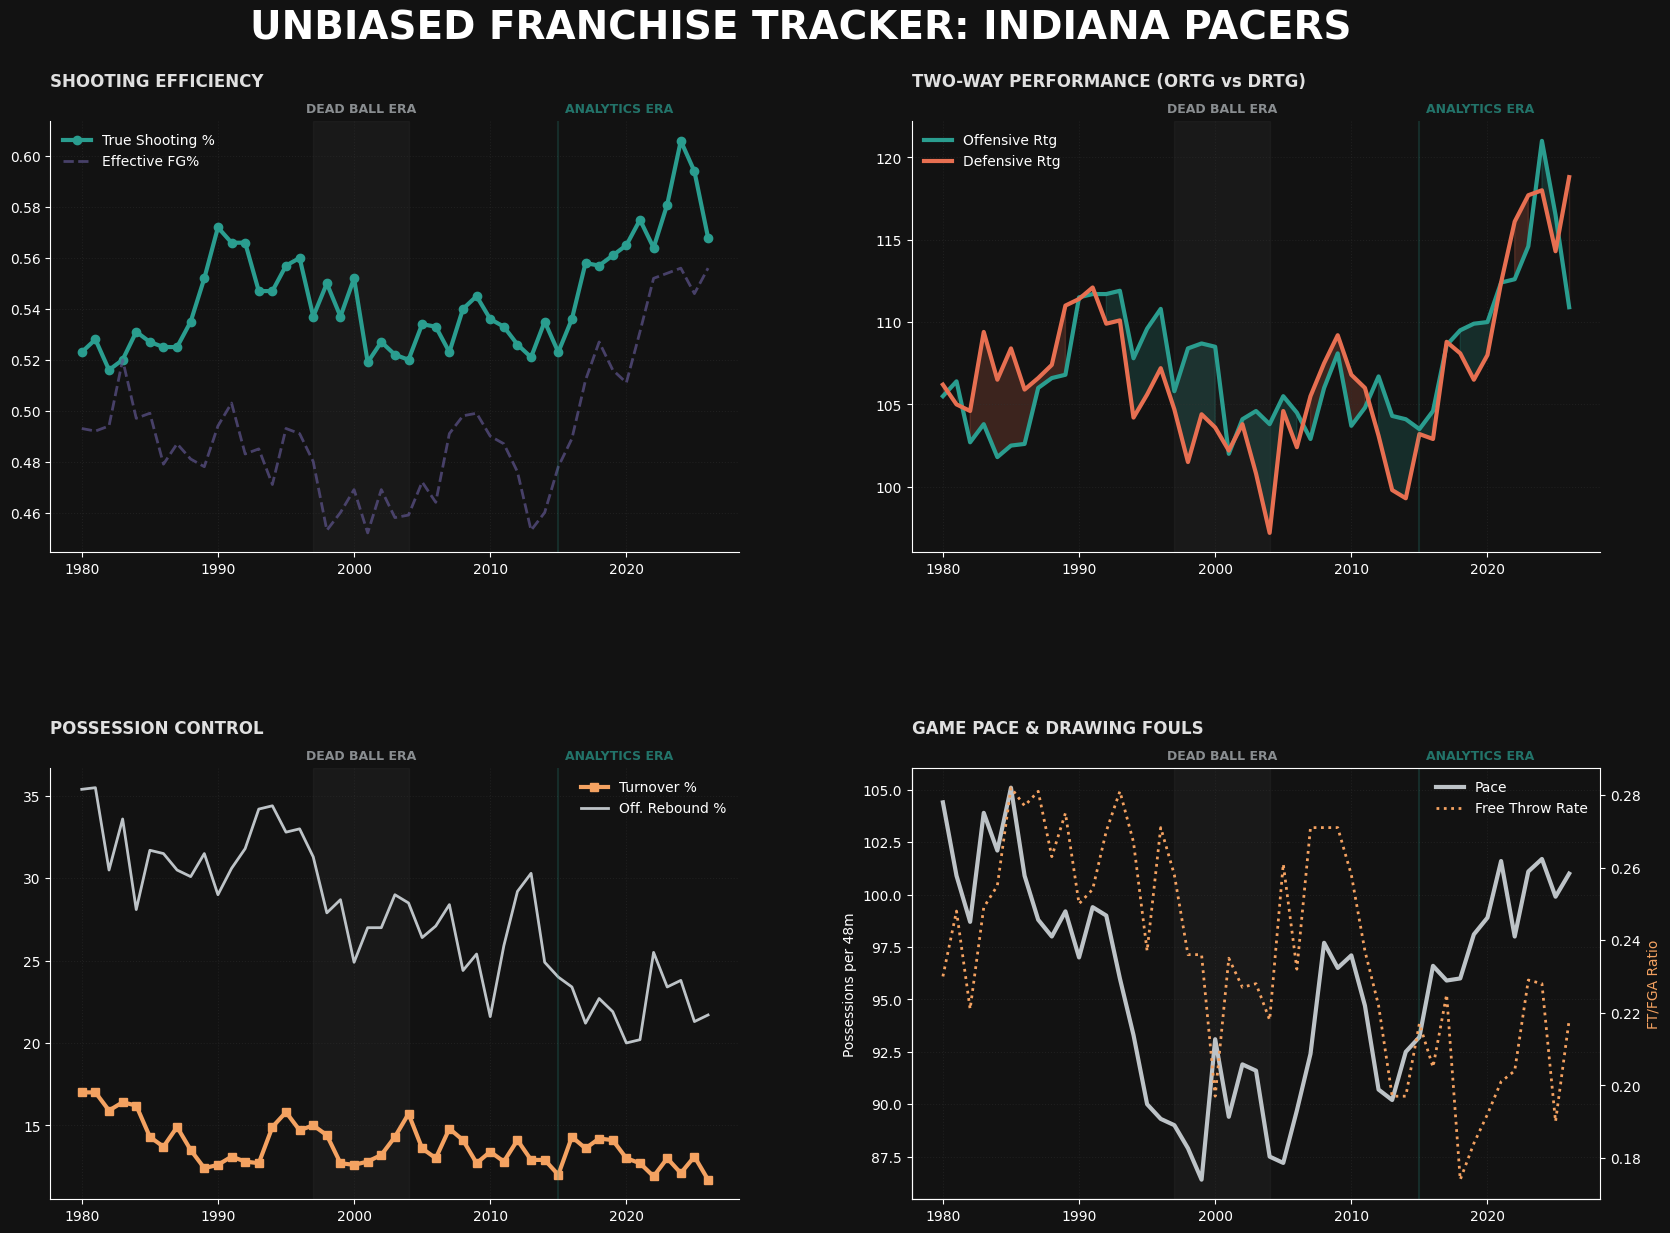

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import os

# --- STYLE CONFIGURATION ---
PURPLE = '#5e548e'
TEAL = '#2a9d8f'
ORANGE = '#f4a261'
SILVER = '#bdc3c7'
RED = '#e76f51'
DARK_BG = '#121212'
GRID_COLOR = '#333333'
TEXT_COLOR = '#E0E0E0'

def get_random_nba_team():
    teams = [
        "Atlanta Hawks", "Boston Celtics", "Brooklyn Nets", "Charlotte Hornets",
        "Chicago Bulls", "Cleveland Cavaliers", "Dallas Mavericks", "Denver Nuggets",
        "Detroit Pistons", "Golden State Warriors", "Houston Rockets", "Indiana Pacers",
        "LA Clippers", "Los Angeles Lakers", "Memphis Grizzlies", "Miami Heat",
        "Milwaukee Bucks", "Minnesota Timberwolves", "New Orleans Pelicans", "New York Knicks",
        "Oklahoma City Thunder", "Orlando Magic", "Philadelphia 76ers", "Phoenix Suns",
        "Portland Trail Blazers", "Sacramento Kings", "San Antonio Spurs", "Toronto Raptors",
        "Utah Jazz", "Washington Wizards"
    ]
    return random.choice(teams)

def plot_unbiased_team_stats():
    target_team = get_random_nba_team()
    path_efficiency = 'data/processed/team_efficiency_trends.csv'
    output_dir = 'data/graphs'
    
    if not os.path.exists(path_efficiency):
        print(f"❌ Error: Efficiency trends file not found.")
        return

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    df = pd.read_csv(path_efficiency)
    team_data = df[df['Team'] == target_team].sort_values('Year')

    plt.style.use('dark_background')
    fig, axes = plt.subplots(2, 2, figsize=(20, 14), facecolor=DARK_BG)
    plt.subplots_adjust(hspace=0.5, wspace=0.25, top=0.88)
    
    ax_list = axes.flatten()

    # --- PANEL 1: SCORING EFFICIENCY ---
    ax1 = ax_list[0]
    ax1.plot(team_data['Year'], team_data['TS%'], color=TEAL, lw=3, marker='o', label='True Shooting %')
    ax1.plot(team_data['Year'], team_data['eFG%'], color=PURPLE, lw=2, ls='--', alpha=0.7, label='Effective FG%')
    ax1.set_title('SHOOTING EFFICIENCY', loc='left', fontweight='black', color=TEXT_COLOR, pad=25)
    ax1.legend(frameon=False)

    # --- PANEL 2: TWO-WAY DOMINANCE ---
    ax2 = ax_list[1]
    ax2.plot(team_data['Year'], team_data['ORtg'], color=TEAL, lw=3, label='Offensive Rtg')
    ax2.plot(team_data['Year'], team_data['DRtg'], color=RED, lw=3, label='Defensive Rtg')
    ax2.fill_between(team_data['Year'], team_data['ORtg'], team_data['DRtg'], 
                     where=(team_data['ORtg'] >= team_data['DRtg']), color=TEAL, alpha=0.2)
    ax2.fill_between(team_data['Year'], team_data['ORtg'], team_data['DRtg'], 
                     where=(team_data['ORtg'] < team_data['DRtg']), color=RED, alpha=0.2)
    ax2.set_title('TWO-WAY PERFORMANCE (ORTG vs DRTG)', loc='left', fontweight='black', color=TEXT_COLOR, pad=25)
    ax2.legend(frameon=False)

    # --- PANEL 3: POSSESSION & REBOUNDING ---
    ax3 = ax_list[2]
    ax3.plot(team_data['Year'], team_data['TOV%'], color=ORANGE, lw=3, marker='s', label='Turnover %')
    ax3.plot(team_data['Year'], team_data['ORB%'], color=SILVER, lw=2, label='Off. Rebound %')
    ax3.set_title('POSSESSION CONTROL', loc='left', fontweight='black', color=TEXT_COLOR, pad=25)
    ax3.legend(frameon=False)

    # --- PANEL 4: VOLUME & PACE (WITH COMBINED LEGEND) ---
    ax4 = ax_list[3]
    l1, = ax4.plot(team_data['Year'], team_data['Pace'], color=SILVER, lw=3, label='Pace')
    ax4_t = ax4.twinx()
    l2, = ax4_t.plot(team_data['Year'], team_data['FT/FGA'], color=ORANGE, lw=2, ls=':', label='Free Throw Rate')
    
    ax4.set_title('GAME PACE & DRAWING FOULS', loc='left', fontweight='black', color=TEXT_COLOR, pad=25)
    ax4.set_ylabel('Possessions per 48m')
    ax4_t.set_ylabel('FT/FGA Ratio', color=ORANGE)
    
    # Merging the legends from the two y-axes
    ax4.legend([l1, l2], [l1.get_label(), l2.get_label()], loc='upper right', frameon=False)

    # --- CLEANUP & ERA LABELS ABOVE THE AXES ---
    for ax in ax_list:
        ax.set_facecolor(DARK_BG)
        ax.grid(color=GRID_COLOR, linestyle=':', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.axvspan(1997, 2004, color='white', alpha=0.03)
        ax.axvline(2015, color=TEAL, ls='-', alpha=0.2)

        ax.text(2000.5, 1.02, 'DEAD BALL ERA', color=SILVER, fontsize=9, 
                fontweight='black', alpha=0.7, ha='center', transform=ax.get_xaxis_transform())
        ax.text(2015.5, 1.02, 'ANALYTICS ERA', color=TEAL, fontsize=9, 
                fontweight='black', alpha=0.7, ha='left', transform=ax.get_xaxis_transform())

    plt.suptitle(f'UNBIASED FRANCHISE TRACKER: {target_team.upper()}', 
                 fontsize=28, fontweight='black', color='white', y=0.96)
    
    # --- SAVE LOGIC ---
    safe_name = target_team.lower().replace(" ", "_")
    save_path = os.path.join(output_dir, f"{safe_name}_dashboard.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor=DARK_BG)
    
    print(f"✅ Dashboard successfully saved to: {save_path}")
    plt.show()

plot_unbiased_team_stats()

### **Conclusion: The New Era of Mathematical Basketball**

The longitudinal analysis of both league-wide data and the Indiana Pacers’ franchise history confirms a fundamental shift in the NBA’s competitive DNA. While the **Dead Ball Era** was defined by a physical, low-possession grind, the **Analytics Era** has introduced a paradigm where efficiency and spacing have rendered traditional defensive metrics obsolete. 

The simultaneous "skyrocketing" of **Defensive Ratings** and **True Shooting %** suggests that modern teams are not necessarily playing "worse" defense, but are instead competing in a **mathematically more difficult environment**. As offensive optimization outpaces traditional defensive schemes, the league has entered a state of "defensive inflation" where points are surrendered at an unprecedented rate despite disciplined execution. 

Ultimately, the data proves that success in the modern NBA is no longer dictated by physical aggression or offensive rebounding, but by a franchise's ability to adapt to a high-pace, high-efficiency meta where every possession is a game of optimized margins.